# Trial 2

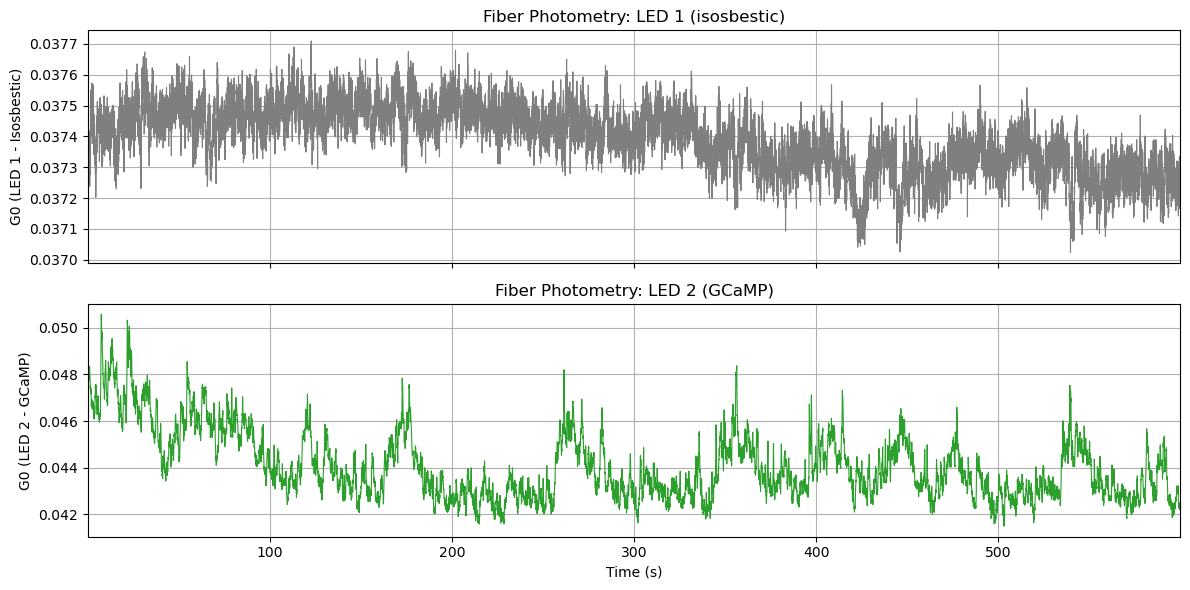

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Preinduction/EPM_FP1/EPM_FP1.csv"
ts_path = "Preinduction/EPM_FP1/timestamp0.csv"

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)
# Keep LED 1 and 2 only
fp = fp[fp["LedState"].isin([1, 2])].copy()

# -------------------------------------------------
# 3. Load timestamp alignment (video start/stop)
# -------------------------------------------------
ts = pd.read_csv(ts_path)
video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 4. Detect signal channel
# -------------------------------------------------
chan = "G0" if "G0" in fp.columns else next(
    c for c in fp.columns
    if pd.api.types.is_numeric_dtype(fp[c])
    and c not in {"SystemTimestamp", "LedState", "Time_video", "Time_s", "Timestamp"}
)

# -------------------------------------------------
# 5. Plot FP traces (LED 1 & 2) only
# -------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1[chan], color="tab:gray", linewidth=0.8)
axes[0].set_ylabel(f"{chan} (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2[chan], color="tab:green", linewidth=0.8)
axes[1].set_ylabel(f"{chan} (LED 2 - GCaMP)")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
axes[1].grid(True)

# --- Shared settings ---
axes[1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


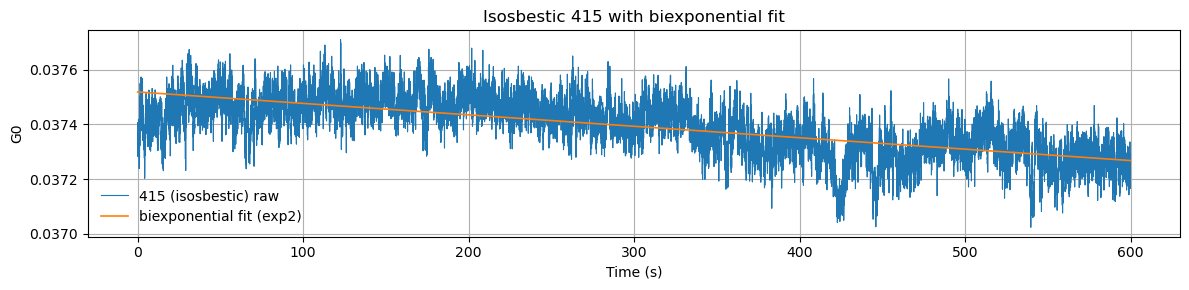

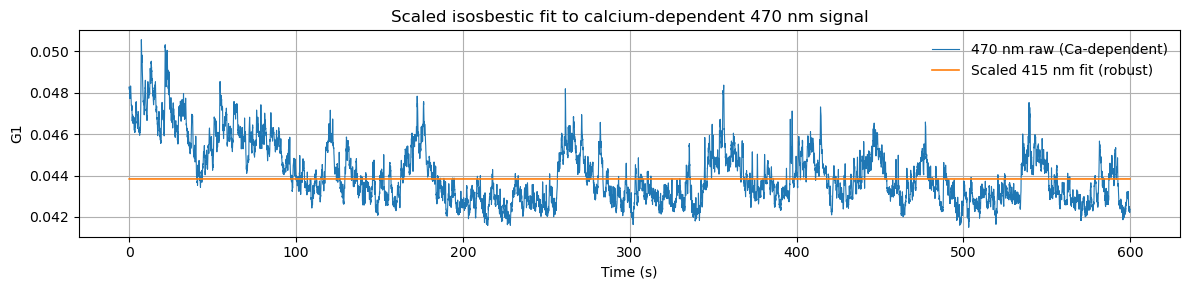

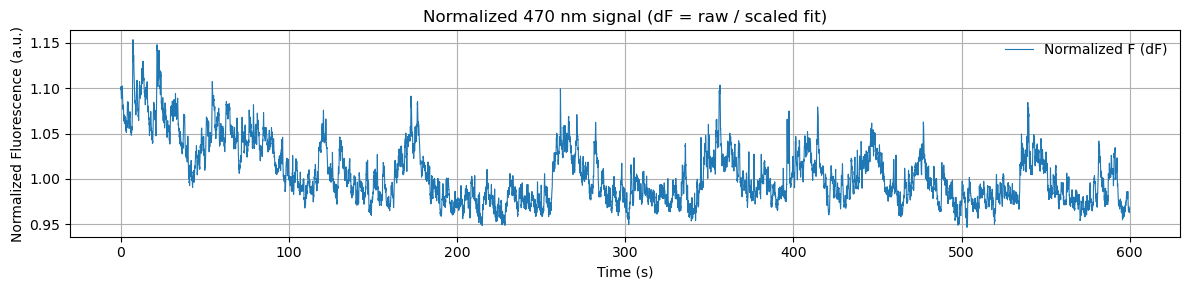

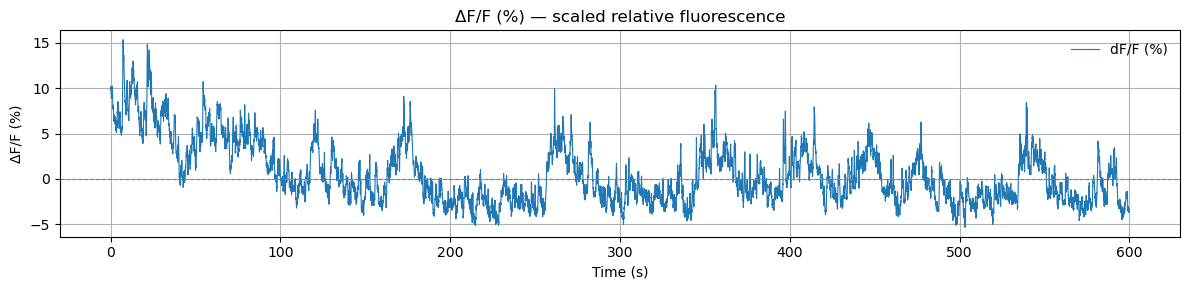

In [3]:
# photobleaching correction
import numpy as np

# 1) Fit isosbestic with biexponential decay

# --- Isosbestic 415: plot + biexponential (MATLAB 'exp2') ---
from scipy.optimize import curve_fit

# MATLAB: exp2 -> a*exp(b*x) + c*exp(d*x)
def exp2(x, a, b, c, d):
    return a * np.exp(b * x) + c * np.exp(d * x)

# Select 415 / isosbestic samples (change to == 2 if needed)
fp415 = fp[fp["LedState"] == 1].copy().sort_values("Time_video")

# y = raw signal; temp_x = frame-index to mimic MATLAB's 'temp_x'
y = fp415["G0"].to_numpy()
temp_x = np.arange(y.size, dtype=float)

# Fit biexponential to 415 using frame-index (robust initial guesses)
p0 = [y.ptp(), -1e-3, 0.5 * y.ptp(), -1e-4]
popt, _ = curve_fit(exp2, temp_x, y, p0=p0, maxfev=20000)

# Evaluate fit at the same indices, plot against time for readability
y_fit = exp2(temp_x, *popt)

fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(fp415["Time_video"], y, linewidth=0.8, label="415 (isosbestic) raw")
ax.plot(fp415["Time_video"], y_fit, linewidth=1.2, label="biexponential fit (exp2)")
ax.set_title("Isosbestic 415 with biexponential fit")
ax.set_xlabel("Time (s)")
ax.set_ylabel("G0")
ax.grid(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
#
#
# 2) Linearly scale that fit to the calcium dependent data (using Robust Fit)

from sklearn.linear_model import HuberRegressor  # robust linear regression

# -------------------------------------------------
# Assume you already have from previous step:
#   fp415      -> dataframe with LedState == 1 (isosbestic)
#   temp_x     -> np.arange(...) used for fitting
#   popt       -> fitted parameters from exp2
# -------------------------------------------------

# --- Get the calcium-dependent 470 channel ---
fp470 = fp[fp["LedState"] == 2].copy().sort_values("Time_video")

# Make sure the two have the same length or align by time if needed
# (Here we simply interpolate the 415 fit to 470 sample times.)
from scipy.interpolate import interp1d
fit_func = lambda x: popt[0]*np.exp(popt[1]*x) + popt[2]*np.exp(popt[3]*x)

# Map time to frame index (same as before)
idx_from_time = interp1d(fp415["Time_video"], temp_x, kind="linear",
                         fill_value="extrapolate", assume_sorted=True)
x470_idx = idx_from_time(fp470["Time_video"])
iso_fit_at_470 = fit_func(x470_idx)

# --- Robust linear scaling: equivalent of MATLAB robustfit(...,'bisquare') ---
huber = HuberRegressor()  # similar spirit to robustfit
huber.fit(iso_fit_at_470.reshape(-1, 1), fp470["G0"].to_numpy())

slope = float(huber.coef_[0])
intercept = float(huber.intercept_)

# MATLAB: FP.lin_fit = FP.fit1(temp_x)*FP.fit2(2)+FP.fit2(1)
fp470["lin_fit"] = intercept + slope * iso_fit_at_470

# --- Plot raw 470 and scaled isosbestic fit ---
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(fp470["Time_video"], fp470["G0"], linewidth=0.8, label="470 nm raw (Ca-dependent)")
ax.plot(fp470["Time_video"], fp470["lin_fit"], linewidth=1.2, label="Scaled 415 nm fit (robust)")
ax.set_title("Scaled isosbestic fit to calcium-dependent 470 nm signal")
ax.set_xlabel("Time (s)")
ax.set_ylabel("G1")
ax.grid(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

#3) Divide your raw 470 data by the scaled fit (dF)

# -------------------------------------------------
# 3) Divide raw 470 data by the scaled fit (dF)
# MATLAB:
#   FP.data(:,4) = FP.data(:,2) ./ FP.lin_fit;
#   plot(FP.data(:,4))
# -------------------------------------------------

# Compute normalized fluorescence (dF)
fp470["dF"] = fp470["G0"] / fp470["lin_fit"]

# --- Plot normalized F value ---
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(fp470["Time_video"], fp470["dF"], linewidth=0.8, label="Normalized F (dF)")
ax.set_title("Normalized 470 nm signal (dF = raw / scaled fit)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Normalized Fluorescence (a.u.)")
ax.grid(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

#4) Calculate dF/F (%)

# -------------------------------------------------
# 4) Calculate dF/F (%) 
# MATLAB:
#   FP.data(:,5) = 100 * (FP.data(:,2) - FP.lin_fit) ./ FP.lin_fit;
#   plot(FP.data(:,5))
# -------------------------------------------------

# Compute dF/F (%) — relative fluorescence change
fp470["dF_F_percent"] = 100 * (fp470["G0"] - fp470["lin_fit"]) / fp470["lin_fit"]

# --- Plot dF/F (%) ---
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(fp470["Time_video"], fp470["dF_F_percent"], linewidth=0.8, label="dF/F (%)")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("ΔF/F (%) — scaled relative fluorescence")
ax.set_xlabel("Time (s)")
ax.set_ylabel("ΔF/F (%)")
ax.grid(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

